In [1]:
import pandas as pd
from prophet import Prophet
import numpy as np
import os
import datetime
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math

### Read data

In [ ]:
# Define the reference date
reference_date = "2026-04-11"
previous_date = "2026-04-04"

In [3]:
rvdss = pd.read_csv(f'Target_rvdss_data_{reference_date}.csv', delimiter=',')
print(rvdss.tail())

               ds     location              target      y
21796  2026-01-31           nt  pct wk flu lab det   3.12
21797  2026-01-31           nu  pct wk flu lab det   6.67
21798  2026-01-31  territories  pct wk flu lab det  10.64
21799  2026-01-31           mb  pct wk flu lab det   1.76
21800  2026-01-31           ca  pct wk flu lab det   7.46


In [4]:
rvdss['ds'] = pd.to_datetime(rvdss['ds']) 
rvdss['location'] = rvdss['location'].astype(str) 
rvdss = rvdss.sort_values(by=['ds', 'location'])
print(rvdss.tail())

              ds     location                target      y
12338 2026-01-31  territories    pct wk rsv lab det   2.82
21798 2026-01-31  territories    pct wk flu lab det  10.64
2888  2026-01-31           yt  pct wk covid lab det   0.00
12335 2026-01-31           yt    pct wk rsv lab det   2.00
21795 2026-01-31           yt    pct wk flu lab det  20.41


In [5]:
fcst = pd.read_csv(f'{reference_date}-VTSanghani-PRIME.csv')
fcst_stretched = pd.read_csv(f'{reference_date}-VTSanghani-PRIME.csv')

fcst['data'] = 'ORIG' 
fcst_stretched['data'] = 'STRETCHED'


fcst['output_type_id'] = fcst['output_type_id'].astype(str)
fcst_stretched['output_type_id'] = fcst_stretched['output_type_id'].astype(str)

fcst = fcst.loc[
    fcst['output_type_id'].isin(['0.025', '0.25', '0.5', '0.75', '0.975'])
]

fcst_stretched = fcst_stretched.loc[
    fcst_stretched['output_type_id'].isin(['0.025', '0.25', '0.5', '0.75', '0.975'])
]

fcst = fcst.pivot_table(
    index=['reference_date', 'target_end_date', 'target', 'horizon', 'location', 'data'],
    columns='output_type_id',
    values='value'
).reset_index()

fcst_stretched = fcst_stretched.pivot_table(
    index=['reference_date', 'target_end_date', 'target', 'horizon', 'location', 'data'],
    columns='output_type_id',
    values='value'
).reset_index()

print(fcst.head(2))
print(fcst_stretched.head(2))

output_type_id reference_date target_end_date                target  horizon  \
0                  2026-02-07      2026-01-31  pct wk covid lab det       -1   
1                  2026-02-07      2026-01-31  pct wk covid lab det       -1   

output_type_id  location  data  0.025  0.25  0.5  0.75  0.975  
0                     ab  ORIG    0.0   1.0  4.0   6.0    8.0  
1               atlantic  ORIG    0.0   2.0  6.0  11.0   13.0  
output_type_id reference_date target_end_date                target  horizon  \
0                  2026-02-07      2026-01-31  pct wk covid lab det       -1   
1                  2026-02-07      2026-01-31  pct wk covid lab det       -1   

output_type_id  location       data  0.025  0.25  0.5  0.75  0.975  
0                     ab  STRETCHED    0.0   1.0  4.0   6.0    8.0  
1               atlantic  STRETCHED    0.0   2.0  6.0  11.0   13.0  


In [6]:
fcst = fcst
fcst['target_end_date'] = pd.to_datetime(fcst['target_end_date']) 
# fcst['model'] = 'VT-PRIME'

fcst = fcst[['target_end_date', 'target', 'horizon', 'location', 'data', '0.025', '0.25', '0.5', '0.75', '0.975', 'data']]
# fcst.columns = forecasts.columns
fcst.head()

output_type_id,target_end_date,target,horizon,location,data,0.025,0.25,0.5,0.75,0.975,data
0,2026-01-31,pct wk covid lab det,-1,ab,ORIG,0.0,1.0,4.0,6.0,8.0,ORIG
1,2026-01-31,pct wk covid lab det,-1,atlantic,ORIG,0.0,2.0,6.0,11.0,13.0,ORIG
2,2026-01-31,pct wk covid lab det,-1,bc,ORIG,0.0,1.0,3.0,5.0,7.0,ORIG
3,2026-01-31,pct wk covid lab det,-1,ca,ORIG,0.0,2.0,5.0,8.0,10.0,ORIG
4,2026-01-31,pct wk covid lab det,-1,mb,ORIG,0.0,2.0,6.0,10.0,13.0,ORIG


In [7]:
# forecasts = pd.concat([forecasts, fcst], ignore_index=True)
forecasts = fcst
forecasts.head()

output_type_id,target_end_date,target,horizon,location,data,0.025,0.25,0.5,0.75,0.975,data
0,2026-01-31,pct wk covid lab det,-1,ab,ORIG,0.0,1.0,4.0,6.0,8.0,ORIG
1,2026-01-31,pct wk covid lab det,-1,atlantic,ORIG,0.0,2.0,6.0,11.0,13.0,ORIG
2,2026-01-31,pct wk covid lab det,-1,bc,ORIG,0.0,1.0,3.0,5.0,7.0,ORIG
3,2026-01-31,pct wk covid lab det,-1,ca,ORIG,0.0,2.0,5.0,8.0,10.0,ORIG
4,2026-01-31,pct wk covid lab det,-1,mb,ORIG,0.0,2.0,6.0,10.0,13.0,ORIG


In [8]:
rvdss['ds'].unique()
start_date = '2024-11-30'
end_date = reference_date
true_data = rvdss[(rvdss['ds'] >= start_date) & (rvdss['ds'] <= end_date)]
true_data.head() 
true_data['ds'].unique()

<DatetimeArray>
['2024-11-30 00:00:00', '2024-12-07 00:00:00', '2024-12-14 00:00:00',
 '2024-12-21 00:00:00', '2024-12-28 00:00:00', '2025-01-04 00:00:00',
 '2025-01-11 00:00:00', '2025-01-18 00:00:00', '2025-01-25 00:00:00',
 '2025-02-01 00:00:00', '2025-02-08 00:00:00', '2025-02-15 00:00:00',
 '2025-02-22 00:00:00', '2025-03-01 00:00:00', '2025-03-08 00:00:00',
 '2025-03-15 00:00:00', '2025-03-22 00:00:00', '2025-03-29 00:00:00',
 '2025-04-05 00:00:00', '2025-04-12 00:00:00', '2025-04-19 00:00:00',
 '2025-04-26 00:00:00', '2025-05-03 00:00:00', '2025-05-10 00:00:00',
 '2025-05-17 00:00:00', '2025-05-24 00:00:00', '2025-05-31 00:00:00',
 '2025-06-07 00:00:00', '2025-06-14 00:00:00', '2025-06-21 00:00:00',
 '2025-06-28 00:00:00', '2025-07-05 00:00:00', '2025-07-12 00:00:00',
 '2025-07-19 00:00:00', '2025-07-26 00:00:00', '2025-08-02 00:00:00',
 '2025-08-09 00:00:00', '2025-08-16 00:00:00', '2025-08-23 00:00:00',
 '2025-08-30 00:00:00', '2025-09-06 00:00:00', '2025-09-13 00:00:00',
 '20

In [9]:
# Ensure that 'target_end_date' is datetime in both DataFrames
forecasts['target_end_date'] = pd.to_datetime(forecasts['target_end_date'])
true_data['ds'] = pd.to_datetime(true_data['ds'])

# Unique locations and targets
locations = true_data['location'].unique()
targets = true_data['target'].unique()

/tmp/ipykernel_355119/2617807693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  true_data['ds'] = pd.to_datetime(true_data['ds'])


In [10]:
true_data

,ds,location,target,y
1845,2024-11-30,ab,pct wk covid lab det,9.84
1855,2024-11-30,atlantic,pct wk covid lab det,6.04
11682,2024-11-30,atlantic,pct wk rsv lab det,2.79
21142,2024-11-30,atlantic,pct wk flu lab det,1.91
1853,2024-11-30,bc,pct wk covid lab det,4.69
...,...,...,...,...
12338,2026-01-31,territories,pct wk rsv lab det,2.82
21798,2026-01-31,territories,pct wk flu lab det,10.64
2888,2026-01-31,yt,pct wk covid lab det,0.00
12335,2026-01-31,yt,pct wk rsv lab det,2.00


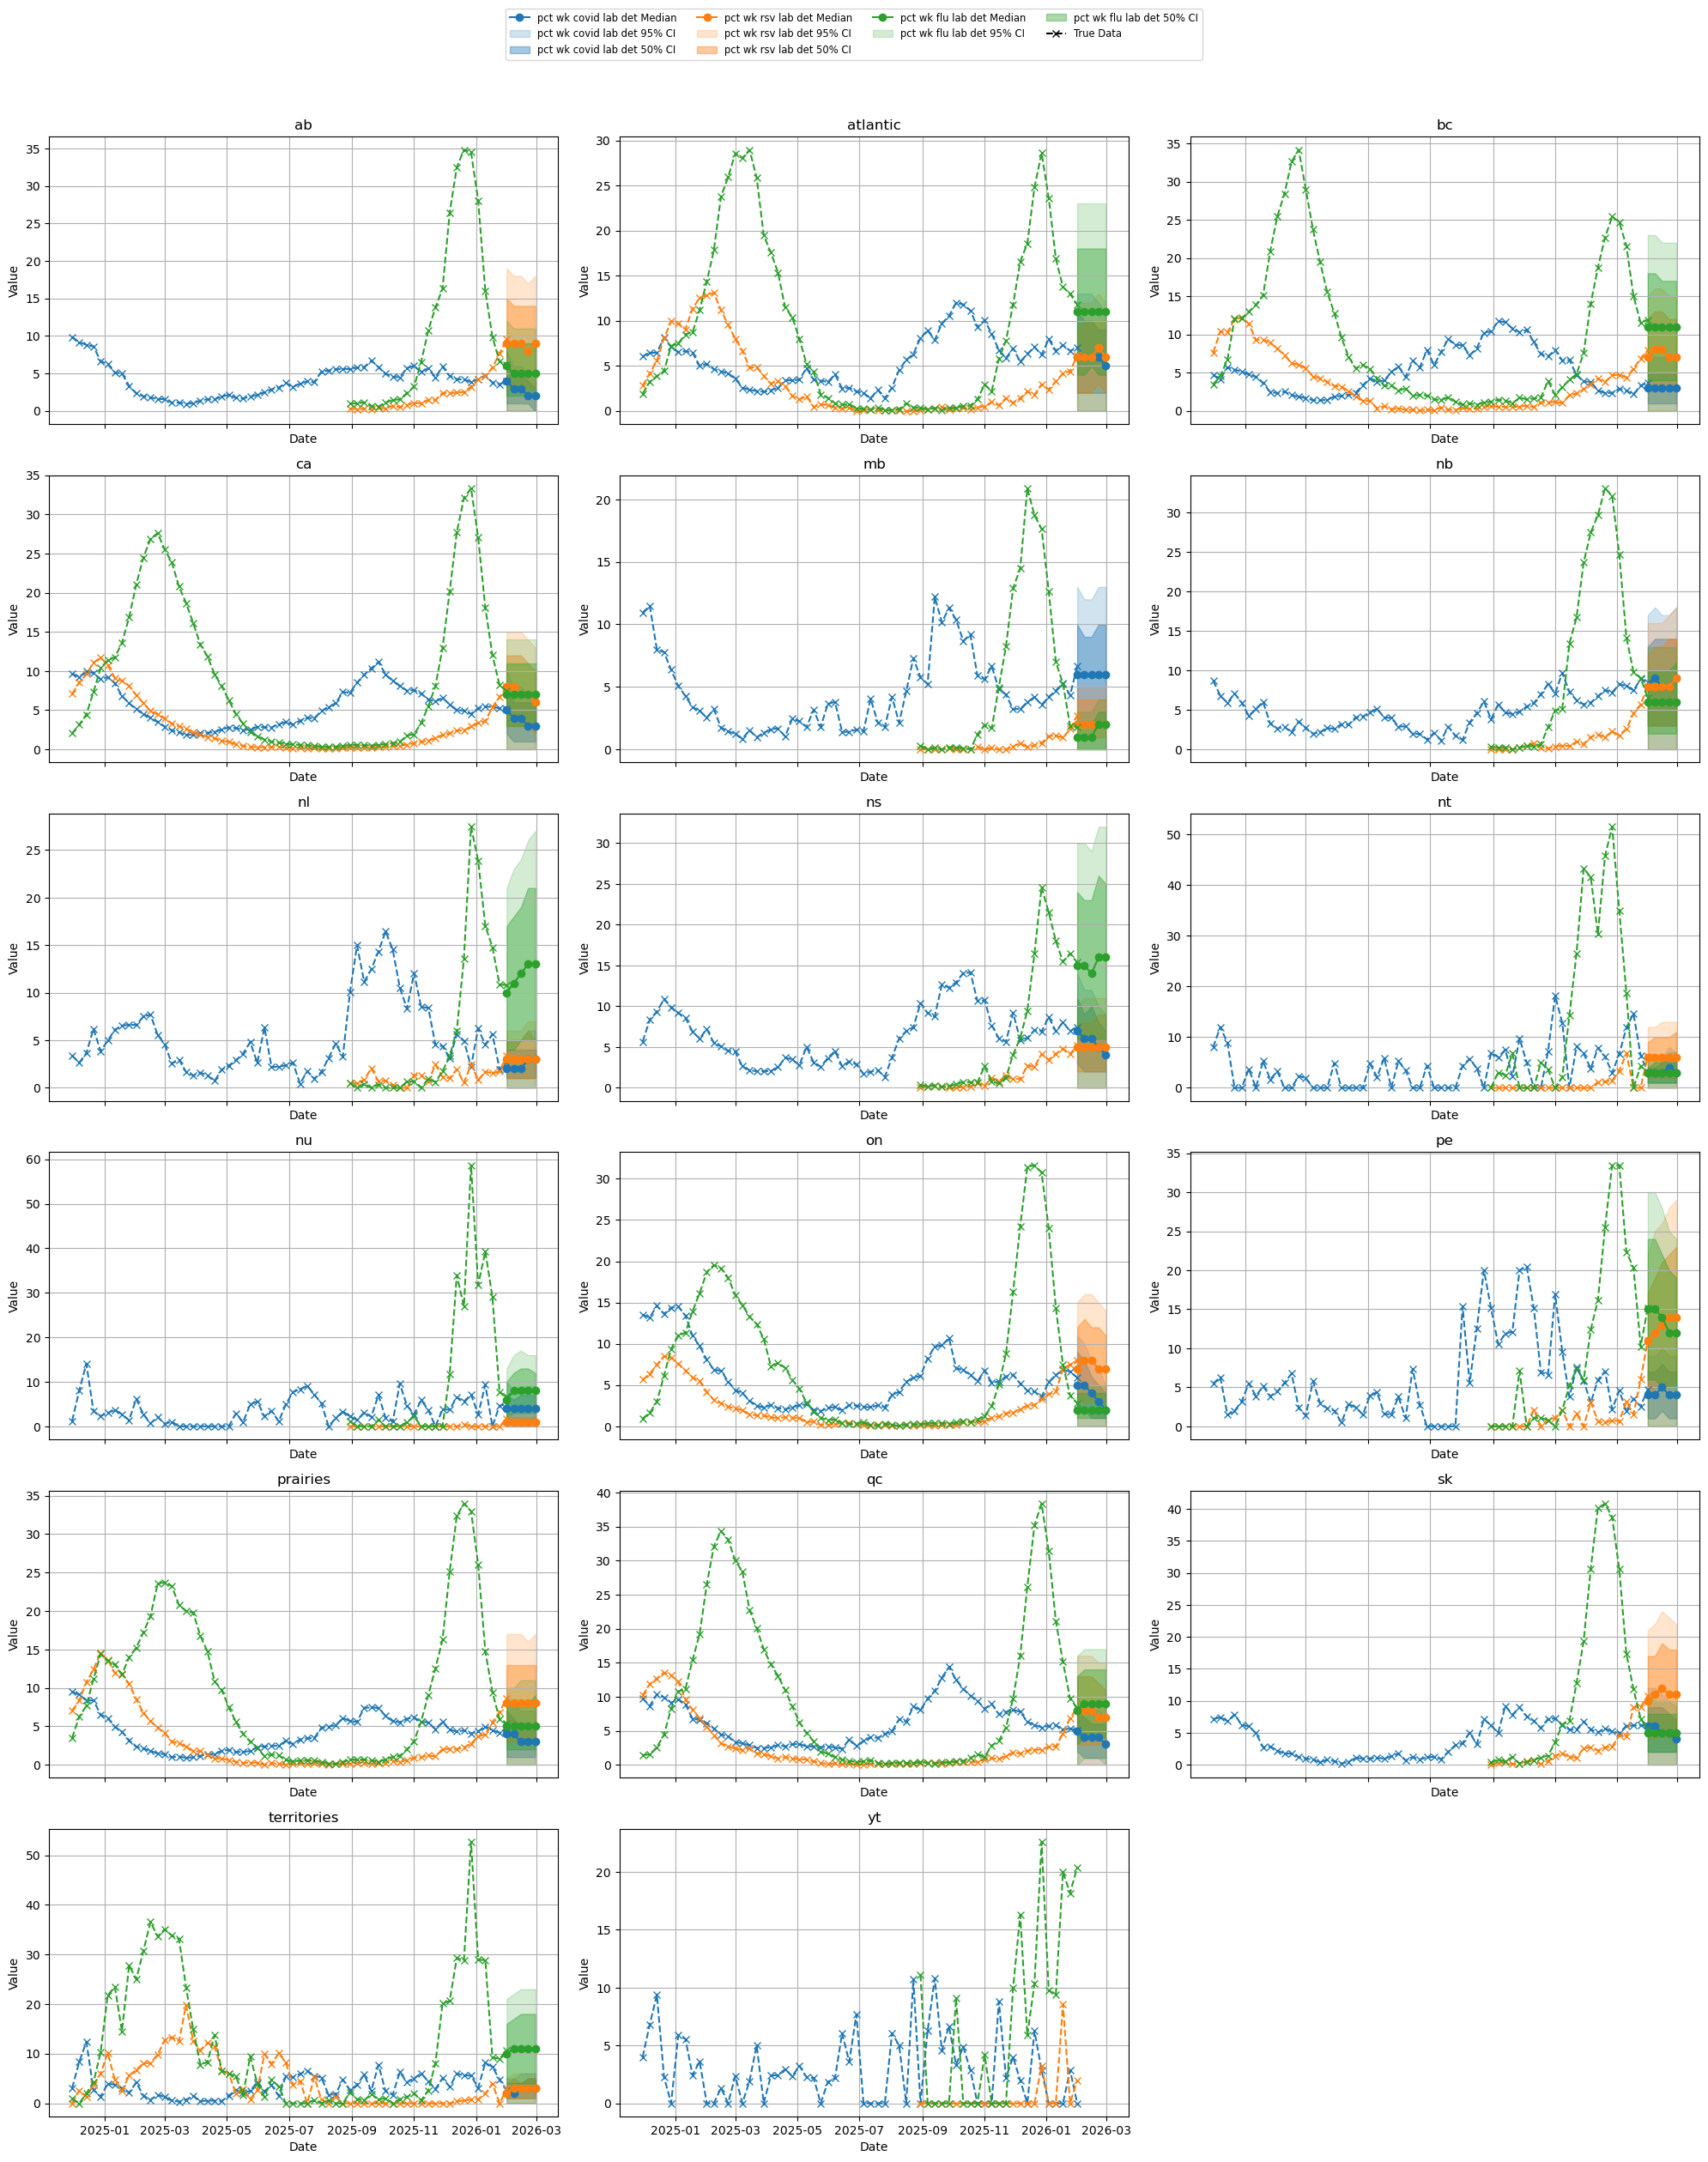

In [11]:
# Define a color mapping for each target
color_map = {target: plt.cm.tab10(i % 10) for i, target in enumerate(targets)}

# Create subplots for each location
num_cols = 3  # Number of columns for panels
num_rows = (len(locations) + num_cols - 1) // num_cols  # Calculate rows based on locations
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows), sharex=True, sharey=False)
axes = axes.flatten()

# Store handles and labels for the legend
handles, labels = [], []

# Plot each location in a separate panel
for i, location in enumerate(locations):
    ax = axes[i]
    loc_data = forecasts[forecasts['location'] == location]
    true_data_loc = true_data[true_data['location'] == location]
    
    for target in targets:
        target_data = loc_data[loc_data['target'] == target]
        true_target = true_data_loc[true_data_loc['target'] == target]
        
        # Use the same color for true and forecast data of each target
        color = color_map[target]
        
        # Plot the true data (y)
        ax.plot(true_target['ds'], true_target['y'], linestyle='--', marker='x', color=color, label=f'{target} True')
        
        # Plot the median (0.5)
        line_median, = ax.plot(target_data['target_end_date'], target_data['0.5'], linestyle='-', marker='o', color=color, label=f'{target} Median')
        
        # Add shaded regions for quantile ranges
        shadow_95 = ax.fill_between(target_data['target_end_date'], target_data['0.025'], target_data['0.975'], color=color, alpha=0.2, label=f'{target} 95% CI')
        shadow_50 = ax.fill_between(target_data['target_end_date'], target_data['0.25'], target_data['0.75'], color=color, alpha=0.4, label=f'{target} 50% CI')
        
        # Collect handles and labels only once
        if i == 0:
            handles.extend([line_median, shadow_95, shadow_50])
            labels.extend([f'{target} Median', f'{target} 95% CI', f'{target} 50% CI'])
    
    ax.set_title(location)
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.grid(True)

# Turn off unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a single legend above the plots
fig.legend(handles + [plt.Line2D([0], [0], linestyle='--', marker='x', color='black')], 
           labels + ['True Data'], loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, fontsize='small')

plt.tight_layout()
plt.show()

In [12]:
# ------ STOP HERE ------